In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
os.chdir("..")
#%mldev import

In [2]:
print("Staprting Limit_to_Delta_Function.ipynb ...")
#%mldev start

Staprting Limit_to_Delta_Function.ipynb ...


```yaml

#%mldev nb_context

Limit_to_Delta_Function:
  - import
  - start
  - experiment_mode
  - paths
  - rc
  - prepare_data
  - plot
  - results
```

In [3]:
experiment_mode = 'mldev'
#%mldev experiment_mode

In [4]:
# run this cell if you are in Jupyter and not running the notebook with mldev
experiment_mode = 'jupyter'

In [5]:
path = os.getenv("MLDEV_DELTA_LOOP_PATH", default="results")
save_path = os.getenv("MLDEV_SAVEFIGURES_PATH", default="figures")
os.makedirs(save_path, exist_ok=True)
#%mldev paths

In [6]:
plt.rc('axes', titlesize=40, titleweight='bold') #fontsize of the title
plt.rc('axes', labelsize=30) #fontsize of the x and y labels
plt.rc('xtick', labelsize=30) #fontsize of the x tick labels
plt.rc('ytick', labelsize=30) #fontsize of the y tick labels
plt.rc('legend', fontsize=35) #fontsize of the legend
plt.rc('figure', figsize=(12, 8)) # figure size
#%mldev rc

In [7]:
def prepare_data(path, control_strategy="none", control_init=0.1, run_times=10, 
                 dataset_name='california', model_name="ridgecv_model"):
    # preparing our data
    if control_strategy != "none":
        directory = f"{path}/{dataset_name}/{model_name}/{control_strategy}_{control_init}"
    else:
        directory = f"{path}/{dataset_name}/{model_name}/none"
    steps, r2_score, N_t, mean_price = [], [], [], []
    N_0, mean_price_0 = None, None
    for trial in range(run_times):
        data = pd.read_csv(f"{directory}/{trial}/results.csv")
        steps += list(data["t"])
        r2_score += list(data["r2_score"])
        if N_0 is None:
            N_0 = data["N_t"][0]
            mean_price_0 = data["mean_price"][0]
        N_t += list(data["N_t"] / N_0)
        mean_price += list(data["mean_price"] / mean_price_0)
    
    return steps, r2_score, N_t, mean_price

#%mldev prepare_data

In [8]:
def plot(control_strategy_list, control_init=0.1, dataset_name='california', 
         model_name="ridgecv_model", run_times=10, figsize=(18, 12), 
         experiment_mode='jupyter', saving=False):
    fig_1, axs_1 = plt.subplots(ncols=1, figsize=figsize)
    fig_2, axs_2 = plt.subplots(ncols=2, figsize=figsize)
    axs = [axs_2[0], axs_1, axs_2[1]]
    # Remove the empty subplot
    #fig.delaxes(axs[0][1])
    #fig.suptitle(f"Control init = {control_init}", fontsize=25)
    colors = ["blue", "red", "green"]
    #control_names = control_strategy_list
    control_names_map = {
        "none": "Нулевое управление", 
        "greedy": "Жадное управление", 
        "smart_greedy": "Аккуратное управление"
    }
    titles = [
        "r2-score", 
        "Кол-во домов в системе (нормированное)", 
        "Средняя цена\n(нормированная)"
    ]
    j = 1
    for control_strategy, color in zip(control_strategy_list, colors):
        data = prepare_data(
                path=path, control_strategy=control_strategy,
                control_init=control_init, run_times=run_times, 
                dataset_name=dataset_name, model_name=model_name,
            )
        for i, (y, title, ax) in enumerate(zip(data[1:], titles, axs)):
            ax.set_xlabel(r"Шаг $t$")
            label = control_names_map[control_strategy] if i == 1 else None
            sns.lineplot(x=data[0], y=y, label=label,
                         color=color, marker=None, ax=ax)
            ax.set_title(title)
            ax.grid(True)
            print(f"{j}/{len(control_strategy_list)*3} is done")
            j += 1
    #fig_1.legend()
    fig_1.tight_layout()
    fig_2.tight_layout()
    if saving:
        fig_1.savefig(f"{save_path}/N_{dataset_name}_{control_strategy}_{int(control_init*100)}.png")
        fig_2.savefig(f"{save_path}/r2-y_{dataset_name}_{control_strategy}_{int(control_init*100)}_N.png")
        fig_1.savefig(f"{save_path}/N_{dataset_name}_{control_strategy}_{int(control_init*100)}.pdf")
        fig_2.savefig(f"{save_path}/r2-y_{dataset_name}_{control_strategy}_{int(control_init*100)}_N.pdf")
    if experiment_mode == 'jupyter':
        plt.show()
    elif experiment_mode == 'mldev':
        plt.close()
    else:
        raise ValueError(f"Wrong experiment mode {experiment_mode}!")
#%mldev plot

## California

AttributeError: module 'pandas' has no attribute 'sort'

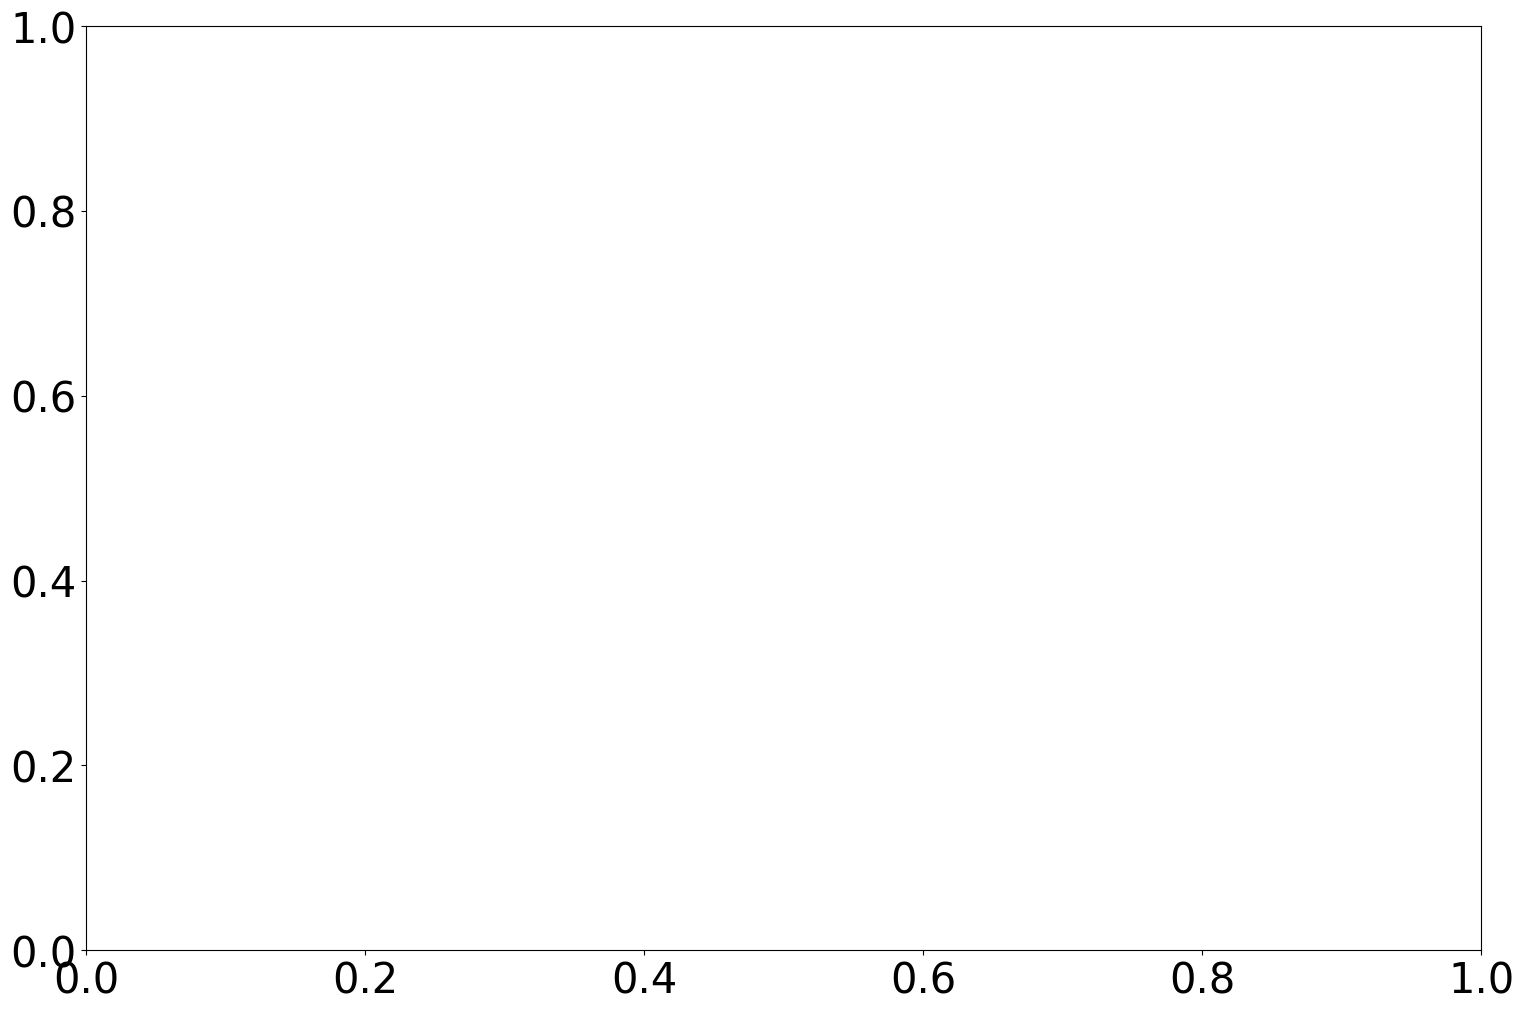

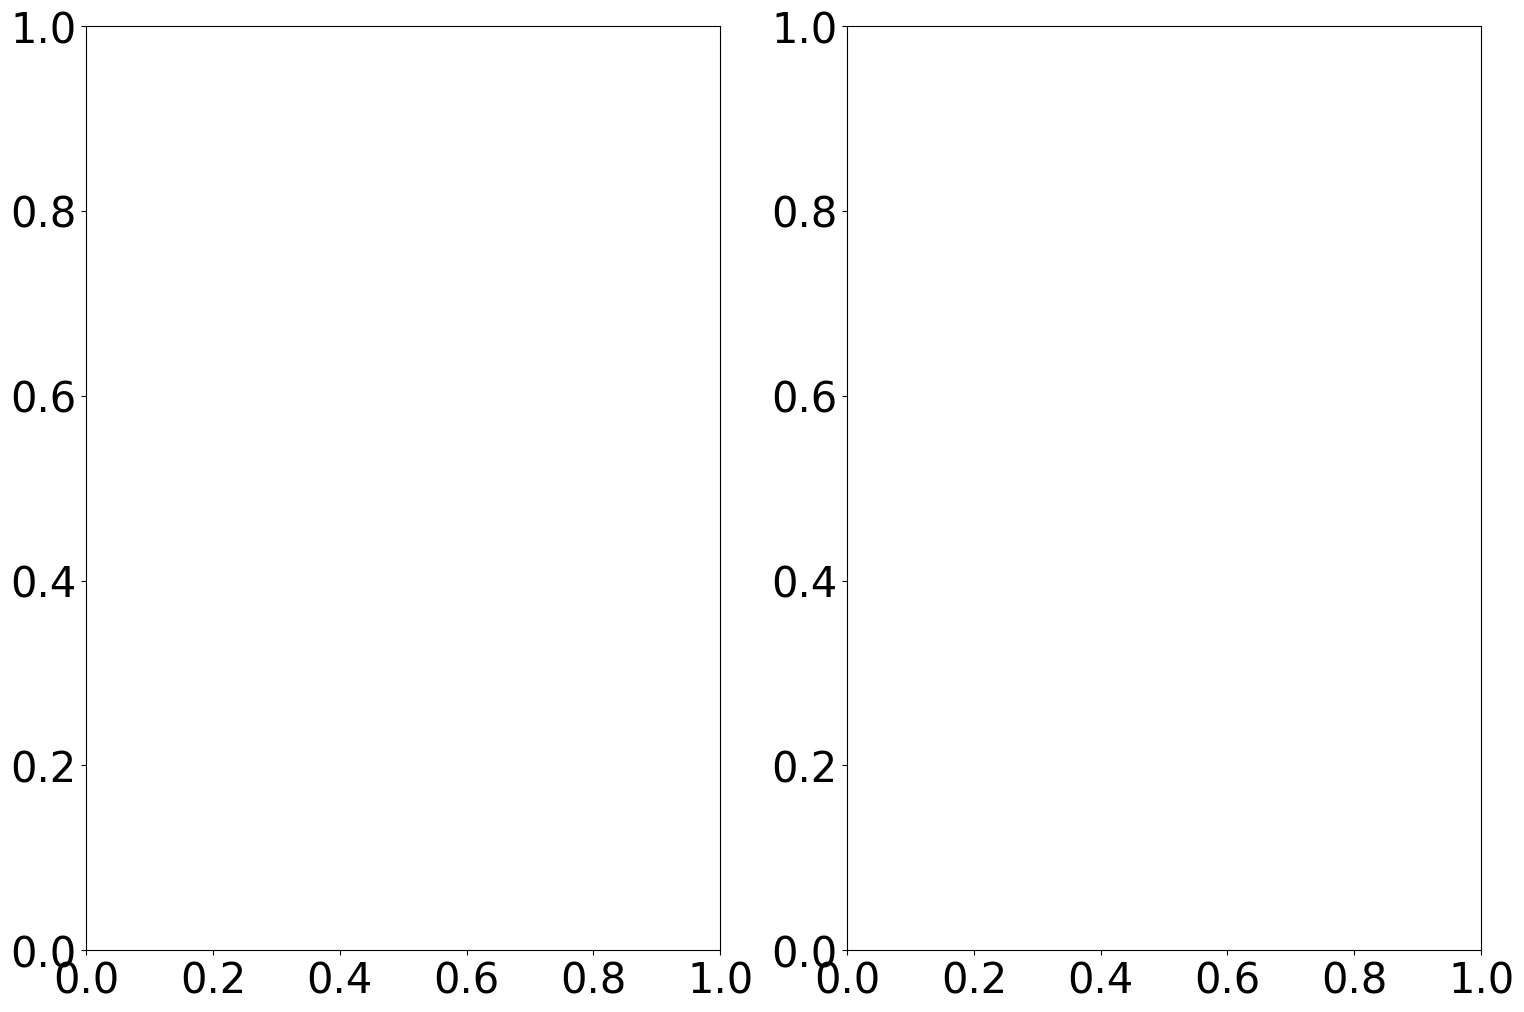

In [92]:
plot(
    control_strategy_list = ["none", "greedy", "smart_greedy"], 
    control_init=0.3, 
    dataset_name="california", 
    model_name="ridgecv_model",
    run_times=10, 
    figsize=(18, 12), experiment_mode=experiment_mode, saving=True,
)
#%mldev results

## Ames Housing

1/6 is done
2/6 is done
3/6 is done
4/6 is done
5/6 is done
6/6 is done


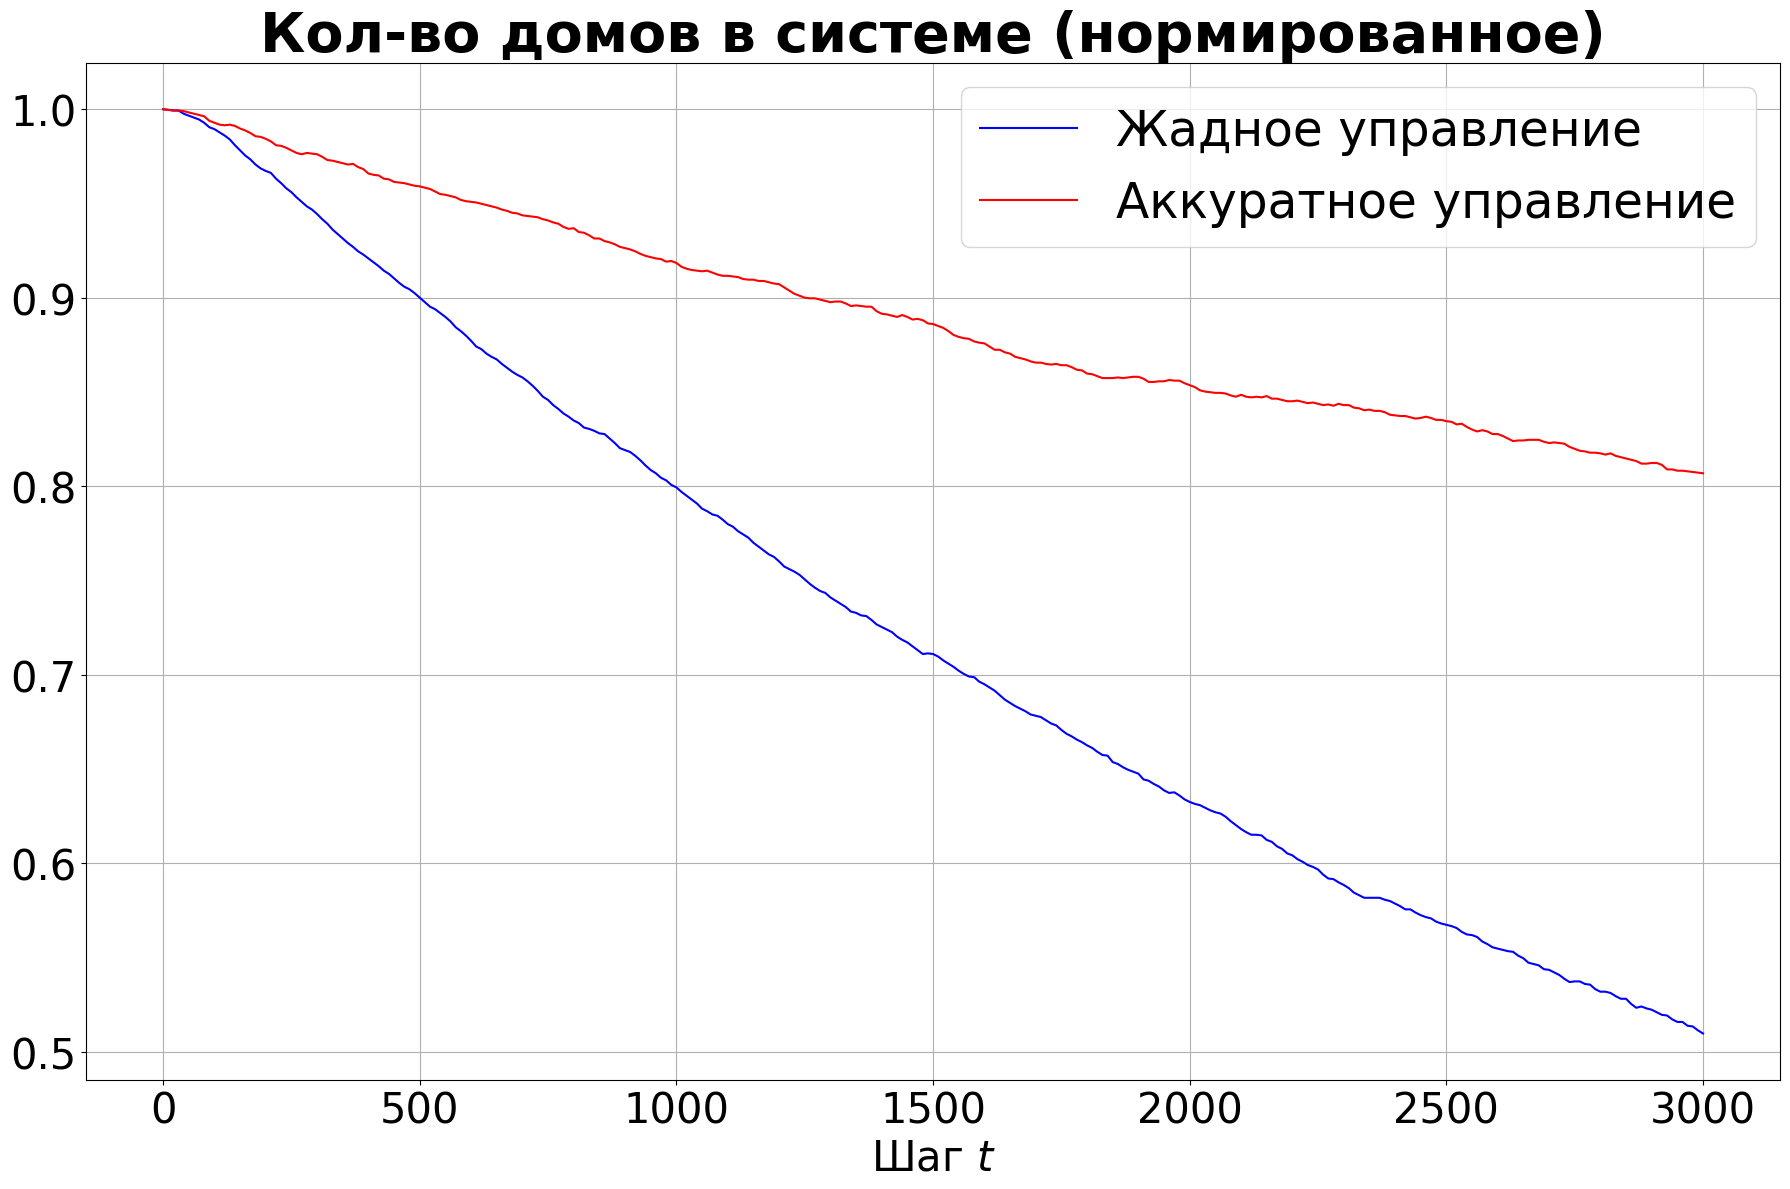

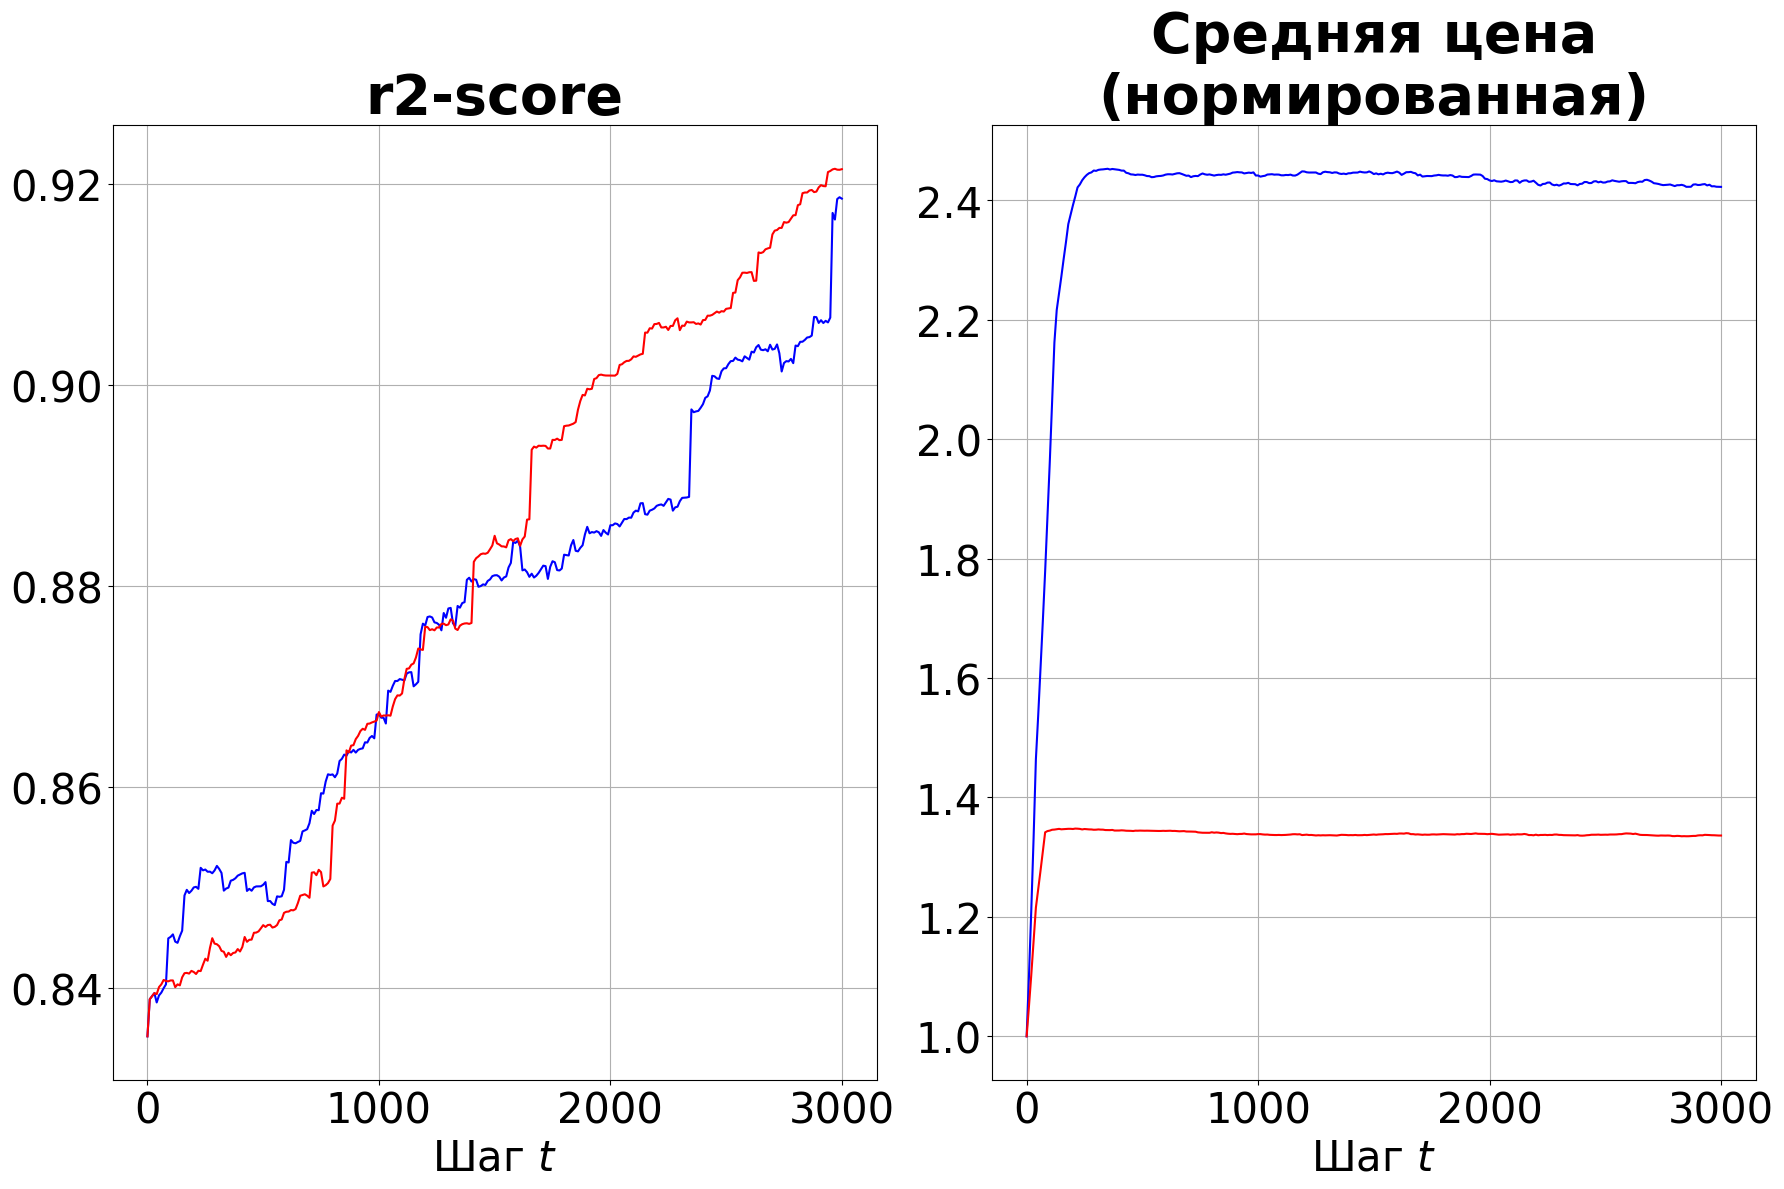

In [40]:
plot(
    control_strategy_list = ["greedy", "smart_greedy"], 
    control_init=0.1, 
    dataset_name="ames_housing", 
    model_name="ridgecv_model",
    run_times=1, 
    figsize=(18, 12), experiment_mode=experiment_mode
)
#%mldev results